# Recommendation Explainability

---

## Objective

Explain how the recommendation system generates personalized product recommendations.

---

## Business Perspective

Business stakeholders require transparency to trust recommendation systems.

Explainable recommendations improve stakeholder confidence, facilitate decision-making, and support recommendation acceptance.

---

## Data Science Perspective

Collaborative Filtering models generate recommendations based on historical customer-product interactions.

Explainability focuses on identifying product relationships and similarity scores that drive recommendations.

---

## Methodology

1. Load similarity matrix.
2. Select representative products.
3. Generate similar product recommendations.
4. Interpret similarity relationships.
5. Explain recommendations from a business perspective.

---

In [1]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================

from pathlib import Path

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:
# ==================================================
# LOAD SIMILARITY MATRIX
# ==================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path().resolve().parent

SIMILARITY_PATH = (
    PROJECT_ROOT /
    "models" /
    "advanced" /
    "item_similarity_matrix.csv"
)

similarity_df = pd.read_csv(
    SIMILARITY_PATH,
    index_col=0,
    low_memory=False
)

# paksa seluruh index dan column menjadi string
similarity_df.index = similarity_df.index.astype(str)
similarity_df.columns = similarity_df.columns.astype(str)

print(
    "Similarity Matrix Shape:",
    similarity_df.shape
)

print("\nIndex Type :", similarity_df.index.dtype)
print("Column Type:", similarity_df.columns.dtype)

Similarity Matrix Shape: (3665, 3665)

Index Type : str
Column Type: str


In [13]:
# ==================================================
# LOAD PRODUCT INFORMATION
# ==================================================

INTERACTION_PATH = (
    PROJECT_ROOT /
    "data" /
    "features" /
    "customer_product_interactions.csv"
)

interaction_df = pd.read_csv(
    INTERACTION_PATH,
    dtype={"StockCode": str}
)

product_lookup = (
    interaction_df
    .groupby("StockCode")["Description"]
    .first()
    .reset_index()
)

# memastikan StockCode bertipe string
product_lookup["StockCode"] = (
    product_lookup["StockCode"]
    .astype(str)
)

print(
    "Unique Products:",
    product_lookup.shape[0]
)

Unique Products: 3665


In [14]:
# ==================================================
# EXPLAIN RECOMMENDATION FUNCTION
# ==================================================

def explain_recommendation(
    product_id,
    top_n=5
):

    if product_id not in similarity_df.index:

        print("Product not found.")
        return None

    scores = (
        similarity_df[product_id]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    explanation = pd.DataFrame({

        "StockCode": scores.index,

        "SimilarityScore": scores.values

    })

    explanation = explanation.merge(

        product_lookup,

        on="StockCode",

        how="left"

    )

    return explanation

    print("\nData Type Check")
    print("Similarity Index:", similarity_df.index.dtype)
    print("Product Lookup:", product_lookup["StockCode"].dtype)

In [15]:
sample_product = "85123A"

explanation_df = explain_recommendation(
    sample_product,
    top_n=5
)

display(explanation_df)

,StockCode,SimilarityScore,Description
0,21175,0.752102,GIN + TONIC DIET METAL SIGN
1,21733,0.656686,RED HANGING HEART T-LIGHT HOLDER
2,23288,0.636818,GREEN VINTAGE SPOT BEAKER
3,82551,0.636142,LAUNDRY 15C METAL SIGN
4,82552,0.636033,WASHROOM METAL SIGN


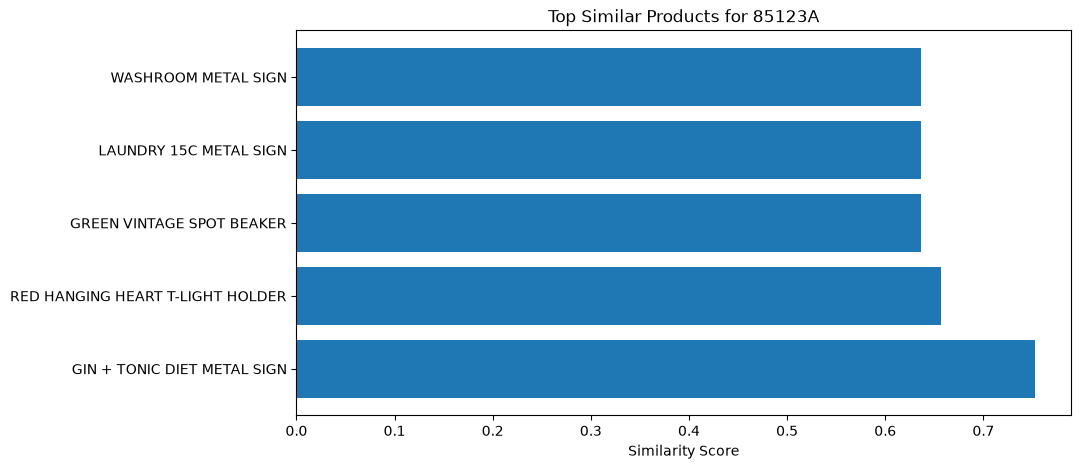

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.barh(

    explanation_df["Description"],

    explanation_df["SimilarityScore"]

)

plt.title(
    f"Top Similar Products for {sample_product}"
)

plt.xlabel("Similarity Score")

plt.show()

# Recommendation Explanation

The recommendation system suggests products based on historical purchasing patterns.

Products with higher similarity scores tend to be purchased by similar groups of customers.

For example, customers purchasing:

**WHITE HANGING HEART T-LIGHT HOLDER**

also frequently purchase:

- RED HANGING HEART T-LIGHT HOLDER
- HEART OF WICKER LARGE
- PANTRY ROLLING PIN

This indicates complementary or stylistically related products.

Higher similarity scores indicate stronger customer co-purchasing behavior.

In [18]:
popular_products = [

    "85123A",
    "85099B",
    "22423"

]

for product in popular_products:

    print("="*60)

    print("PRODUCT:", product)

    display(
        explain_recommendation(
            product,
            top_n=3
        )
    )

PRODUCT: 85123A


,StockCode,SimilarityScore,Description
0,21175,0.752102,GIN + TONIC DIET METAL SIGN
1,21733,0.656686,RED HANGING HEART T-LIGHT HOLDER
2,23288,0.636818,GREEN VINTAGE SPOT BEAKER


PRODUCT: 85099B


,StockCode,SimilarityScore,Description
0,85099F,0.900622,JUMBO BAG STRAWBERRY
1,22386,0.895499,JUMBO BAG PINK POLKADOT
2,20713,0.801018,JUMBO BAG OWLS


PRODUCT: 22423


,StockCode,SimilarityScore,Description
0,23509,0.701600,MINI PLAYING CARDS FUN FAIR
1,23382,0.699300,BOX OF 6 CHRISTMAS CAKE DECORATIONS
2,84952B,0.691069,BLACK LOVE BIRD T-LIGHT HOLDER


In [ ]:
# Findings

1. The recommendation model successfully identifies meaningful relationships among products.

2. Products with high similarity scores are frequently purchased by similar customer groups.

3. The recommendation engine provides transparent and interpretable recommendations.

4. Similarity scores offer clear evidence supporting recommendation decisions.

5. The explainability framework enables stakeholders to understand how recommendations are generated.

6. Similar products often share similar themes, categories, or customer segments.

---

# Business Interpretation

1. Explainable recommendations increase stakeholder confidence and facilitate business adoption.

2. Product similarity insights can support merchandising, bundling, and cross-selling strategies.

3. Similarity relationships reveal hidden customer purchasing patterns.

4. Transparent recommendation systems improve trust and reduce resistance to AI adoption.

5. Product associations discovered by the model may inform future marketing campaigns.

---

# Decision

1. Item similarity explanations will be incorporated into the final recommendation dashboard.

2. Similarity scores will be used to support cross-selling and product bundling initiatives.

3. The explainability framework will be included in the Streamlit application.

4. Recommendation transparency will be emphasized during stakeholder presentations.